This is a script that calculates the vT contours and the Ocean Heat Content for NorESM2-LM, IPSL-CM6A-LR and CESM2.

### **0. Importing packages and functions**

In [1]:
import os

from tos_functions import*
from dask.diagnostics import ProgressBar
from AMOC_functions import rolling_average_ts
from OHC_functions import*
import xesmf as xe

/nird/home/chrikap/.conda/envs/nird_heat_transport/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


# **A. NorESM2-LM**

## **1. Getting the data from NIRD**

### **1.1. meridional velocity (vo)**

In [2]:
experiments = ['piControl', 'abrupt-4xCO2']

vo_piControl_noresm2 = []
vo_x4CO2_noresm2 = []

for experiment in experiments:
            
    folder_path = f'/projects/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/{experiment}/r1i1p1f1/Omon/vo/gr/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 10}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 500*12))

    yearly_vo = yearly_avg(ds)

    if experiment == 'piControl':
    
        vo_piControl_noresm2.append(yearly_vo)
    else: 
        vo_x4CO2_noresm2.append(yearly_vo)

### **1.2. potential temperature (thetao)**

In [4]:
experiments = ['piControl', 'abrupt-4xCO2']

thetao_piControl_noresm2 = []
thetao_x4CO2_noresm2 = []

for experiment in experiments:
            
    folder_path = f'/projects/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/{experiment}/r1i1p1f1/Omon/thetao/gr/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 12}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')

    ds = merged_datasets.isel(time=slice(0, 500*12))

    yearly_thetao = yearly_avg(ds)
    
    if experiment == 'piControl':
    
        thetao_piControl_noresm2 = yearly_thetao
    else: 
        thetao_x4CO2_noresm2 = yearly_thetao

### **1.3. Regridding**

In [5]:
vo_pi_renamed_noresm2 = consistent_naming(vo_piControl_noresm2[0])
vo_x4_renamed_noresm2 = consistent_naming(vo_x4CO2_noresm2[0])

vo_pi_regr_noresm2 = regrid_ocean(vo_pi_renamed_noresm2, "vo", None)
vo_x4_regr_noresm2 = regrid_ocean(vo_x4_renamed_noresm2, "vo", None)

thetao_pi_renamed_noresm2 = consistent_naming(thetao_piControl_noresm2)
thetao_x4_renamed_noresm2 = consistent_naming(thetao_x4CO2_noresm2)

thetao_pi_regr_noresm2 = regrid_ocean(thetao_pi_renamed_noresm2, "thetao", None)
thetao_x4_regr_noresm2 = regrid_ocean(thetao_x4_renamed_noresm2, "thetao", None)

In regrid_file
Regridding maker made
Regridding completed
In regrid_file
Regridding maker made
Regridding completed
In regrid_file
Regridding maker made
Regridding completed
In regrid_file
Regridding maker made
Regridding completed


## **2. Total vT**
### **2.1. Replace 0 with nans**

In [6]:
vo_pi_regr_noresm2['vo'] = vo_pi_regr_noresm2['vo'].where(vo_pi_regr_noresm2['vo'] != 0)
vo_x4_regr_noresm2['vo'] = vo_x4_regr_noresm2['vo'].where(vo_x4_regr_noresm2['vo'] != 0)

thetao_pi_regr_noresm2['thetao'] = thetao_pi_regr_noresm2['thetao'].where(thetao_pi_regr_noresm2['thetao'] != 0)
thetao_x4_regr_noresm2['thetao'] = thetao_x4_regr_noresm2['thetao'].where(thetao_x4_regr_noresm2['thetao'] != 0)

vT_pi_noresm2 = vo_pi_regr_noresm2['vo']*thetao_pi_regr_noresm2['thetao']
vT_x4_noresm2 = vo_x4_regr_noresm2['vo']*thetao_x4_regr_noresm2['thetao']

### Burry them for now

In [6]:
#### vo
#mean_vo_pi_noresm2 = (vo_pi_regr_noresm2['vo'].isel(year = slice(0, 30*12))).mean(dim={'lon', 'year'}).sel(lev=slice(0, 1000)).values

#mean_vo_global_x4_120_150_noresm2 = (vo_x4_regr_noresm2['vo'].isel(year = slice(120*12, 150*12))).mean(dim={'lon', 'year'}).sel(lev=slice(0, 1000)).values
#mean_vo_global_x4_470_500_noresm2 = (vo_x4_regr_noresm2['vo'].isel(year = slice(470*12, 500*12))).mean(dim={'lon', 'year'}).sel(lev=slice(0, 1000)).values

#### thetao
#mean_thetao_pi_noresm2 = (thetao_pi_regr_noresm2['thetao'].isel(year = slice(0, 30*12))).mean(dim={'lon', 'year'}).sel(lev=slice(0, 1000)).values

#mean_thetao_global_x4_120_150_noresm2 = (thetao_x4_regr_noresm2['thetao'].isel(year = slice(120*12, 150*12))).mean(dim={'lon', 'year'}).sel(lev=slice(0, 1000)).values
#mean_thetao_global_x4_470_500_noresm2 = (thetao_x4_regr_noresm2['thetao'].isel(year = slice(470*12, 500*12))).mean(dim={'lon', 'year'}).sel(lev=slice(0, 1000)).values

In [12]:
#os.chdir('/nird/home/chrikap/v_T')

#np.save('mean_vo_pi_noresm2', mean_vo_pi_noresm2)
#np.save('mean_vo_global_x4_120_150_noresm2', mean_vo_global_x4_120_150_noresm2)
#np.save('mean_vo_global_x4_470_500_noresm2', mean_vo_global_x4_470_500_noresm2)
#np.save('mean_thetao_pi_noresm2', mean_thetao_pi_noresm2)
#np.save('mean_thetao_global_x4_120_150_noresm2', mean_thetao_global_x4_120_150_noresm2)
#np.save('mean_thetao_global_x4_470_500_noresm2', mean_thetao_global_x4_470_500_noresm2)

### **2.2. Total, Mean, Eddy**

In [7]:
total_pi_noresm2 = vT_pi_noresm2.isel(year=slice(0, 30)).mean(dim='year', skipna=True)
zonal_total_pi_noresm2 = (total_pi_noresm2.mean(dim='lon', skipna=True)).sel(lev = slice(0, 500)).values

#mean_pi_noresm2 = (vo_pi_regr_noresm2['vo'].isel(time=slice(0, 30*12)).mean(dim='time', skipna=True))*(thetao_pi_regr_noresm2['thetao'].isel(time=slice(0, 30*12)).mean(dim='time', skipna=True))
#zonal_mean_pi_noresm2 = (mean_pi_noresm2.mean(dim='lon', skipna=True)).sel(lev = slice(0, 1000)).values

#eddy_pi_noresm2 = total_pi_noresm2 - mean_pi_noresm2
#zonal_eddy_pi_noresm2 = (eddy_pi_noresm2.mean(dim='lon', skipna=True)).sel(lev = slice(0, 1000)).values

In [9]:
# y120-150
total_x4_120_150_noresm2 = vT_x4_noresm2.isel(year=slice(120, 150)).mean(dim='year')
zonal_total_x4_120_150_noresm2 = (total_x4_120_150_noresm2.mean(dim='lon')).sel(lev=slice(0 ,500)).values

#mean_x4_120_150_noresm2 = (vo_x4_regr_noresm2['vo'].isel(time=slice(120*12, 150*12)).mean(dim='time'))*(thetao_x4_regr_noresm2['thetao'].isel(time=slice(120*12, 150*12)).mean(dim='time'))
#zonal_mean_x4_120_150_noresm2 = (mean_x4_120_150_noresm2.mean(dim='lon')).sel(lev=slice(0 ,1000)).values

#eddy_x4_120_150_noresm2 = total_x4_120_150_noresm2 - mean_x4_120_150_noresm2
#zonal_eddy_x4_120_150_noresm2 = (eddy_x4_120_150_noresm2.mean(dim='lon')).sel(lev=slice(0 ,1000)).values

#y470-500

total_x4_470_500_noresm2 = vT_x4_noresm2.isel(year=slice(120, 150)).mean(dim='year')
zonal_total_x4_470_500_noresm2 = (total_x4_470_500_noresm2.mean(dim='lon')).sel(lev=slice(0 ,500)).values

#mean_x4_470_500_noresm2 = (vo_x4_regr_noresm2['vo'].isel(time=slice(120*12, 150*12)).mean(dim='time'))*(thetao_x4_regr_noresm2['thetao'].isel(time=slice(120*12, 150*12)).mean(dim='time'))
#zonal_mean_x4_470_500_noresm2 = (mean_x4_470_500_noresm2.mean(dim='lon')).sel(lev=slice(0 ,1000)).values

#eddy_x4_470_500_noresm2 = total_x4_470_500_noresm2 - mean_x4_470_500_noresm2
#zonal_eddy_x4_470_500_noresm2 = (eddy_x4_470_500_noresm2.mean(dim='lon')).sel(lev=slice(0 ,1000)).values

# **B. IPSL-CM6A-LR**

## **1. Getting the data from NIRD**

### **1.1. meridional velocity (vo)**

In [10]:
experiments = ['piControl', 'abrupt-4xCO2']

vo_piControl_ipsl = []
vo_x4CO2_ipsl = []

for experiment in experiments:
            
    folder_path = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/{experiment}/r1i1p1f1/Omon/vo/gn/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 12}) for file_name in file_names if file_name.endswith('.nc')]

    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 900*12))
    ds['time'] = to_cftime(ds['time'].values)

    yearly_vo = yearly_avg(ds)

    if experiment == 'piControl':
    
        vo_piControl_ipsl.append(yearly_vo)
    else: 
        vo_x4CO2_ipsl.append(yearly_vo)

### **1.2. potential temperature (thetao)**

In [15]:
experiments = ['piControl', 'abrupt-4xCO2']

thetao_piControl_ipsl = []
thetao_x4CO2_ipsl = []

for experiment in experiments:
            
    folder_path = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/{experiment}/r1i1p1f1/Omon/thetao/gn/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 12}) for file_name in file_names if file_name.endswith('.nc')]

    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 900*12))

    ds['time'] = to_cftime(ds['time'].values)

    yearly_thetao = yearly_avg(ds)

    if experiment == 'piControl':
    
        thetao_piControl_ipsl = yearly_thetao
    else: 
        thetao_x4CO2_ipsl = yearly_thetao

### **1.3. Regridding**

In [16]:
vo_pi_renamed_ipsl = consistent_naming(vo_piControl_ipsl[0])
vo_x4_renamed_ipsl = consistent_naming(vo_x4CO2_ipsl[0])

vo_pi_regr_ipsl = regrid_ocean(vo_pi_renamed_ipsl, "vo", None)
vo_x4_regr_ipsl = regrid_ocean(vo_x4_renamed_ipsl, "vo", None)

thetao_pi_renamed_ipsl = consistent_naming(thetao_piControl_ipsl)
thetao_x4_renamed_ipsl = consistent_naming(thetao_x4CO2_ipsl)

thetao_pi_regr_ipsl = regrid_ocean(thetao_pi_renamed_ipsl, "thetao", None)
thetao_x4_regr_ipsl = regrid_ocean(thetao_x4_renamed_ipsl, "thetao", None)

In regrid_file
Regridding maker made
Regridding completed
In regrid_file
Regridding maker made
Regridding completed
In regrid_file
Regridding maker made
Regridding completed
In regrid_file
Regridding maker made
Regridding completed


## **2. Total vT**
### **Step 3: Replace 0 with nans**

In [17]:
vo_pi_regr_ipsl['vo'] = vo_pi_regr_ipsl['vo'].where(vo_pi_regr_ipsl['vo'] != 0)
vo_x4_regr_ipsl['vo'] = vo_x4_regr_ipsl['vo'].where(vo_x4_regr_ipsl['vo'] != 0)

thetao_pi_regr_ipsl['thetao'] = thetao_pi_regr_ipsl['thetao'].where(thetao_pi_regr_ipsl['thetao'] != 0)
thetao_x4_regr_ipsl['thetao'] = thetao_x4_regr_ipsl['thetao'].where(thetao_x4_regr_ipsl['thetao'] != 0)

vT_pi_ipsl = vo_pi_regr_ipsl['vo']*thetao_pi_regr_ipsl['thetao']
vT_x4_ipsl = vo_x4_regr_ipsl['vo']*thetao_x4_regr_ipsl['thetao']

In [18]:
total_pi_ipsl = vT_pi_ipsl.isel(year=slice(0, 30)).mean(dim='year', skipna=True)
zonal_total_pi_ipsl = total_pi_ipsl.mean(dim='lon', skipna=True).sel(olevel=slice(0 ,500)).values

#mean_pi_ipsl = (vo_pi_regr_ipsl['vo'].isel(time=slice(0, 30*12)).mean(dim='time', skipna=True))*(thetao_pi_regr_ipsl['thetao'].isel(time=slice(0, 30*12)).mean(dim='time', skipna=True))
#zonal_mean_pi_ipsl = mean_pi_ipsl.mean(dim='lon', skipna=True)

#eddy_pi_ipsl = total_pi_ipsl - mean_pi_ipsl
#zonal_eddy_pi_ipsl = eddy_pi_ipsl.mean(dim='lon', skipna=True)

In [19]:
total_x4_120_150_ipsl = vT_x4_ipsl.isel(year=slice(120, 150)).mean(dim='year')
zonal_total_x4_120_150_ipsl = (total_x4_120_150_ipsl.mean(dim='lon')).sel(olevel=slice(0 ,500)).values

total_x4_470_500_ipsl = vT_x4_ipsl.isel(year=slice(470, 500)).mean(dim='year')
zonal_total_x4_470_500_ipsl = (total_x4_470_500_ipsl.mean(dim='lon')).sel(olevel=slice(0 ,500)).values

total_x4_870_900_ipsl = vT_x4_ipsl.isel(year=slice(870, 900)).mean(dim='year')
zonal_total_x4_870_900_ipsl = (total_x4_870_900_ipsl.mean(dim='lon')).sel(olevel=slice(0 ,500)).values


# **C. CESM2**

## **1. Getting the data from NIRD**

### **1.1. meridional velocity (vo)**

In [20]:
experiments = ['piControl', 'abrupt-4xCO2']

vo_piControl_cesm2 = []
vo_x4CO2_cesm2 = []

for experiment in experiments:
            
    folder_path = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/NCAR/CESM2/{experiment}/r1i1p1f1/Omon/vo/gn/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 10}) for file_name in file_names if file_name.endswith('.nc')]

    # --- Add extra file for abrupt-4xCO2 ---
    if experiment == 'abrupt-4xCO2':
        extra_file_1 = '/datalake/NS9560K/ESGF/rawdata/model/chrikap/vo/CESM2/vo_Omon_CESM2_abrupt-4xCO2_r1i1p1f1_gn_000101-015012.nc'
        extra_ds_1 = xr.open_dataset(extra_file_1, chunks={'time': 10})
        # Prepend it
        datasets = [extra_ds_1] + datasets    
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 999*12))

    yearly_vo = yearly_avg(ds)

    if experiment == 'piControl':
    
        vo_piControl_cesm2.append(yearly_vo)
    else: 
        vo_x4CO2_cesm2.append(yearly_vo)

### **1.2. potential temperature**

In [27]:
experiments = ['piControl', 'abrupt-4xCO2']

thetao_piControl_cesm2 = []
thetao_x4CO2_cesm2 = []

for experiment in experiments:
            
    folder_path = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/NCAR/CESM2/{experiment}/r1i1p1f1/Omon/thetao/gn/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 10}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 999*12))

    yearly_thetao = yearly_avg(ds)

    if experiment == 'piControl':
    
        thetao_piControl_cesm2.append(yearly_thetao)
    else: 
        thetao_x4CO2_cesm2.append(yearly_thetao)

### **1.3. Regridding**

In [28]:
vo_pi_renamed_cesm2 = consistent_naming(vo_piControl_cesm2[0])
vo_x4_renamed_cesm2 = consistent_naming(vo_x4CO2_cesm2[0])

vo_pi_regr_cesm2 = regrid_ocean(vo_pi_renamed_cesm2, "vo", None)
vo_x4_regr_cesm2 = regrid_ocean(vo_x4_renamed_cesm2, "vo", None)

thetao_pi_renamed_cesm2 = consistent_naming(thetao_piControl_cesm2[0])
thetao_x4_renamed_cesm2 = consistent_naming(thetao_x4CO2_cesm2[0])

thetao_pi_regr_cesm2 = regrid_ocean(thetao_pi_renamed_cesm2, "thetao", None)
thetao_x4_regr_cesm2 = regrid_ocean(thetao_x4_renamed_cesm2, "thetao", None)

In regrid_file
Regridding maker made
Regridding completed
In regrid_file
Regridding maker made
Regridding completed
In regrid_file
Regridding maker made
Regridding completed
In regrid_file
Regridding maker made
Regridding completed


## **2. Total vT**
### **Step 3: Replace 0 with nans**

In [29]:
vo_pi_regr_cesm2['vo'] = vo_pi_regr_cesm2['vo'].where(vo_pi_regr_cesm2['vo'] != 0)
vo_x4_regr_cesm2['vo'] = vo_x4_regr_cesm2['vo'].where(vo_x4_regr_cesm2['vo'] != 0)

thetao_pi_regr_cesm2['thetao'] = thetao_pi_regr_cesm2['thetao'].where(thetao_pi_regr_cesm2['thetao'] != 0)
thetao_x4_regr_cesm2['thetao'] = thetao_x4_regr_cesm2['thetao'].where(thetao_x4_regr_cesm2['thetao'] != 0)

vT_pi_cesm2 = vo_pi_regr_cesm2['vo']*thetao_pi_regr_cesm2['thetao']
vT_x4_cesm2 = vo_x4_regr_cesm2['vo']*thetao_x4_regr_cesm2['thetao']

In [30]:
total_pi_cesm2 = vT_pi_cesm2.isel(year=slice(0, 30)).mean(dim='year', skipna=True)
zonal_total_pi_cesm2 = total_pi_cesm2.mean(dim='lon', skipna=True).sel(lev=slice(0 ,500*100)).values

#mean_pi_cesm2 = (vo_pi_regr_cesm2['vo'].isel(time=slice(0, 30*12)).mean(dim='time', skipna=True))*(thetao_pi_regr_cesm2['thetao'].isel(time=slice(0, 30*12)).mean(dim='time', skipna=True))
#zonal_mean_pi_cesm2 = mean_pi_cesm2.mean(dim='lon', skipna=True)

#eddy_pi_cesm2 = total_pi_cesm2 - mean_pi_cesm2
#zonal_eddy_pi_cesm2 = eddy_pi_cesm2.mean(dim='lon', skipna=True)

In [31]:
total_x4_120_150_cesm2 = vT_x4_cesm2.isel(year=slice(120, 150)).mean(dim='year')
zonal_total_x4_120_150_cesm2 = (total_x4_120_150_cesm2.mean(dim='lon')).sel(lev=slice(0 ,500*100)).values

total_x4_470_500_cesm2 = vT_x4_cesm2.isel(year=slice(470, 500)).mean(dim='year')
zonal_total_x4_470_500_cesm2 = (total_x4_470_500_cesm2.mean(dim='lon')).sel(lev=slice(0 ,500*100)).values

total_x4_870_900_cesm2 = vT_x4_cesm2.isel(year=slice(870, 900)).mean(dim='year')
zonal_total_x4_870_900_cesm2 = (total_x4_870_900_cesm2.mean(dim='lon')).sel(lev=slice(0 ,500*100)).values

total_x4_970_999_cesm2 = vT_x4_cesm2.isel(year=slice(970, 999)).mean(dim='year')
zonal_total_x4_970_999_cesm2 = (total_x4_970_999_cesm2.mean(dim='lon')).sel(lev=slice(0 ,500*100)).values

In [35]:
os.chdir('/nird/home/chrikap/v_T')

np.save('zonal_total_pi_noresm2', zonal_total_pi_noresm2)
np.save('zonal_total_x4_120_150_noresm2', zonal_total_x4_120_150_noresm2)
np.save('zonal_total_x4_470_500_noresm2', zonal_total_x4_470_500_noresm2)

np.save('zonal_total_pi_ipsl', zonal_total_pi_ipsl)
np.save('zonal_total_x4_120_150_ipsl', zonal_total_x4_120_150_ipsl)
np.save('zonal_total_x4_470_500_ipsl', zonal_total_x4_470_500_ipsl)
np.save('zonal_total_x4_870_900_ipsl', zonal_total_x4_870_900_ipsl)

np.save('zonal_total_pi_cesm2', zonal_total_pi_cesm2)
np.save('zonal_total_x4_120_150_cesm2', zonal_total_x4_120_150_cesm2)
np.save('zonal_total_x4_470_500_cesm2', zonal_total_x4_470_500_cesm2)
np.save('zonal_total_x4_870_900_cesm2', zonal_total_x4_870_900_cesm2)
np.save('zonal_total_x4_970_999_cesm2', zonal_total_x4_970_999_cesm2)

In [27]:
os.chdir('/nird/home/chrikap/v_T')

zonal_total_pi_noresm2 = np.load('zonal_total_pi_noresm2.npy')
zonal_total_x4_120_150_noresm2 = np.load('zonal_total_x4_120_150_noresm2.npy')
zonal_total_x4_470_500_noresm2 = np.load('zonal_total_x4_470_500_noresm2.npy')

#zonal_total_x4_120_150_ipsl = np.load('zonal_total_x4_120_150_ipsl.npy')
#zonal_total_x4_470_500_ipsl = np.load('zonal_total_x4_470_500_ipsl.npy')
#zonal_total_x4_870_900_ipsl = np.load('zonal_total_x4_870_900_ipsl.npy')

#zonal_total_x4_120_150_cesm2 = np.load('zonal_total_x4_120_150_ipsl.npy')
#zonal_total_x4_470_500_cesm2 = np.load('zonal_total_x4_470_500_ipsl.npy')
#zonal_total_x4_870_900_cesm2 = np.load('zonal_total_x4_870_900_ipsl.npy')
#zonal_total_x4_970_999_cesm2 = np.load('zonal_total_x4_970_999_ipsl.npy')

# **D. Plotting mean (vT) piControl**

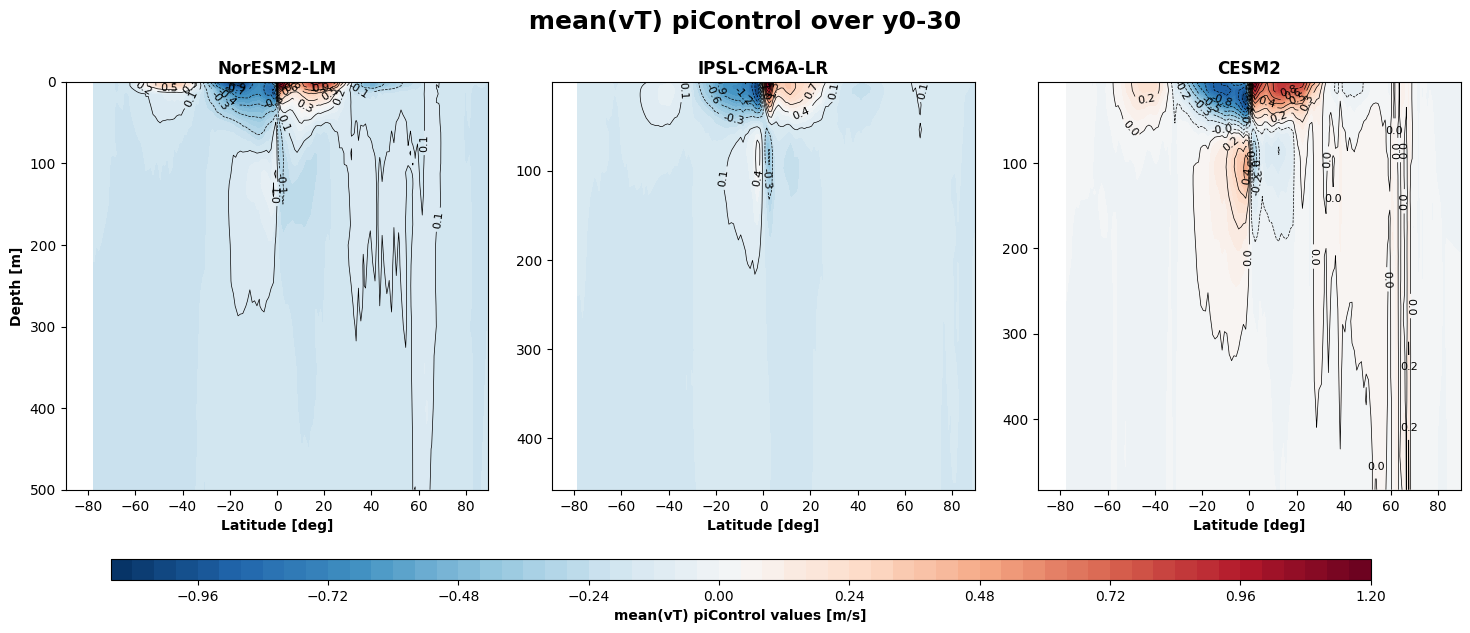

In [32]:
data_piControl_list = [zonal_total_pi_noresm2, zonal_total_pi_ipsl, zonal_total_pi_cesm2]
titles = ["NorESM2-LM", "IPSL-CM6A-LR", "CESM2"]

fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 1])

# Copy and modify cmap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="white")

for i, data_piControl in enumerate(data_piControl_list):

    if titles[i]== "NorESM2-LM":        

        lat = total_pi_noresm2.lat
        lev = total_pi_noresm2.lev.sel(lev=slice(0, 500))

    elif titles[i]== "CESM2":        

        lat = total_pi_cesm2.lat
        lev = (total_pi_cesm2.lev/100).sel(lev=slice(0, 500*100))

    else:
        lat = total_pi_ipsl.lat
        lev = total_pi_ipsl.olevel.sel(olevel=slice(0, 500))
        
    data = data_piControl#.values

    # Plot
    ax = fig.add_subplot(gs[0, i])

    im_pi = ax.contourf(
        lat, lev,
        data,
        levels=60,
        cmap="RdBu_r",
        
    )#vmin=-0.02, vmax=0.02

    levels = im_pi.levels
    neg_levels = levels[levels < 0]
    pos_levels = levels[levels > 0]

    # Negative contours (dashed)
    pi_neg = ax.contour(lat, lev,
        (data),
        levels=neg_levels[::3],
        colors='k',
        linestyles='dashed',
        linewidths=0.5
    )
    
    # Positive contours (solid)
    pi_pos = ax.contour(lat, lev,
        (data),
        levels=pos_levels[::3],
        colors='k',
        linestyles='solid',
        linewidths=0.5
    )
    ax.set_title(titles[i], fontweight='bold')
    ax.invert_yaxis()
    
    if i == 0:
        ax.set_ylabel("Depth [m]", fontweight="bold")

    # Add x-label to all panels
    ax.set_xlabel("Latitude [deg]", fontweight="bold")

    ax.clabel(pi_neg, inline=True, fmt="%1.1f", fontsize=8)
    ax.clabel(pi_pos, inline=True, fmt="%1.1f", fontsize=8)

# ---- Horizontal colorbar spanning all panels ----
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.035])  # [left, bottom, width, height]
cbar = fig.colorbar(im_pi, cax=cbar_ax, orientation="horizontal")
cbar.set_label("mean(vT) piControl values [m/s]", fontweight='bold')

fig.suptitle(" mean(vT) piControl over y0-30", fontsize=18, weight='bold', y=1)
plt.subplots_adjust(top=0.88, bottom=0.20, wspace=0.15)

plt.show()

In [37]:
# ---- DATASETS ----

noresm_datasets = [
    (zonal_total_x4_120_150_noresm2,  "NorESM2-LM: y120–150", "NorESM2-LM"),
    (zonal_total_x4_470_500_noresm2,  "NorESM2-LM: y470–500", "NorESM2-LM"),
]

ipsl_datasets = [
    (zonal_total_x4_120_150_ipsl, "IPSL-CM6A-LR: y120–150", "IPSL-CM6A-LR"),
    (zonal_total_x4_470_500_ipsl, "IPSL-CM6A-LR: y470–500", "IPSL-CM6A-LR"),
    (zonal_total_x4_870_900_ipsl, "IPSL-CM6A-LR: y870–900", "IPSL-CM6A-LR"),
]

cesm_datasets = [
    (zonal_total_x4_120_150_cesm2, "CESM2: y120–150", "CESM2"),
    (zonal_total_x4_470_500_cesm2, "CESM2: y470–500", "CESM2"),
    (zonal_total_x4_870_900_cesm2, "CESM2: y870–900", "CESM2"),
    (zonal_total_x4_970_999_cesm2, "CESM2: y970–999", "CESM2"),
]

all_groups = [noresm_datasets, ipsl_datasets, cesm_datasets]

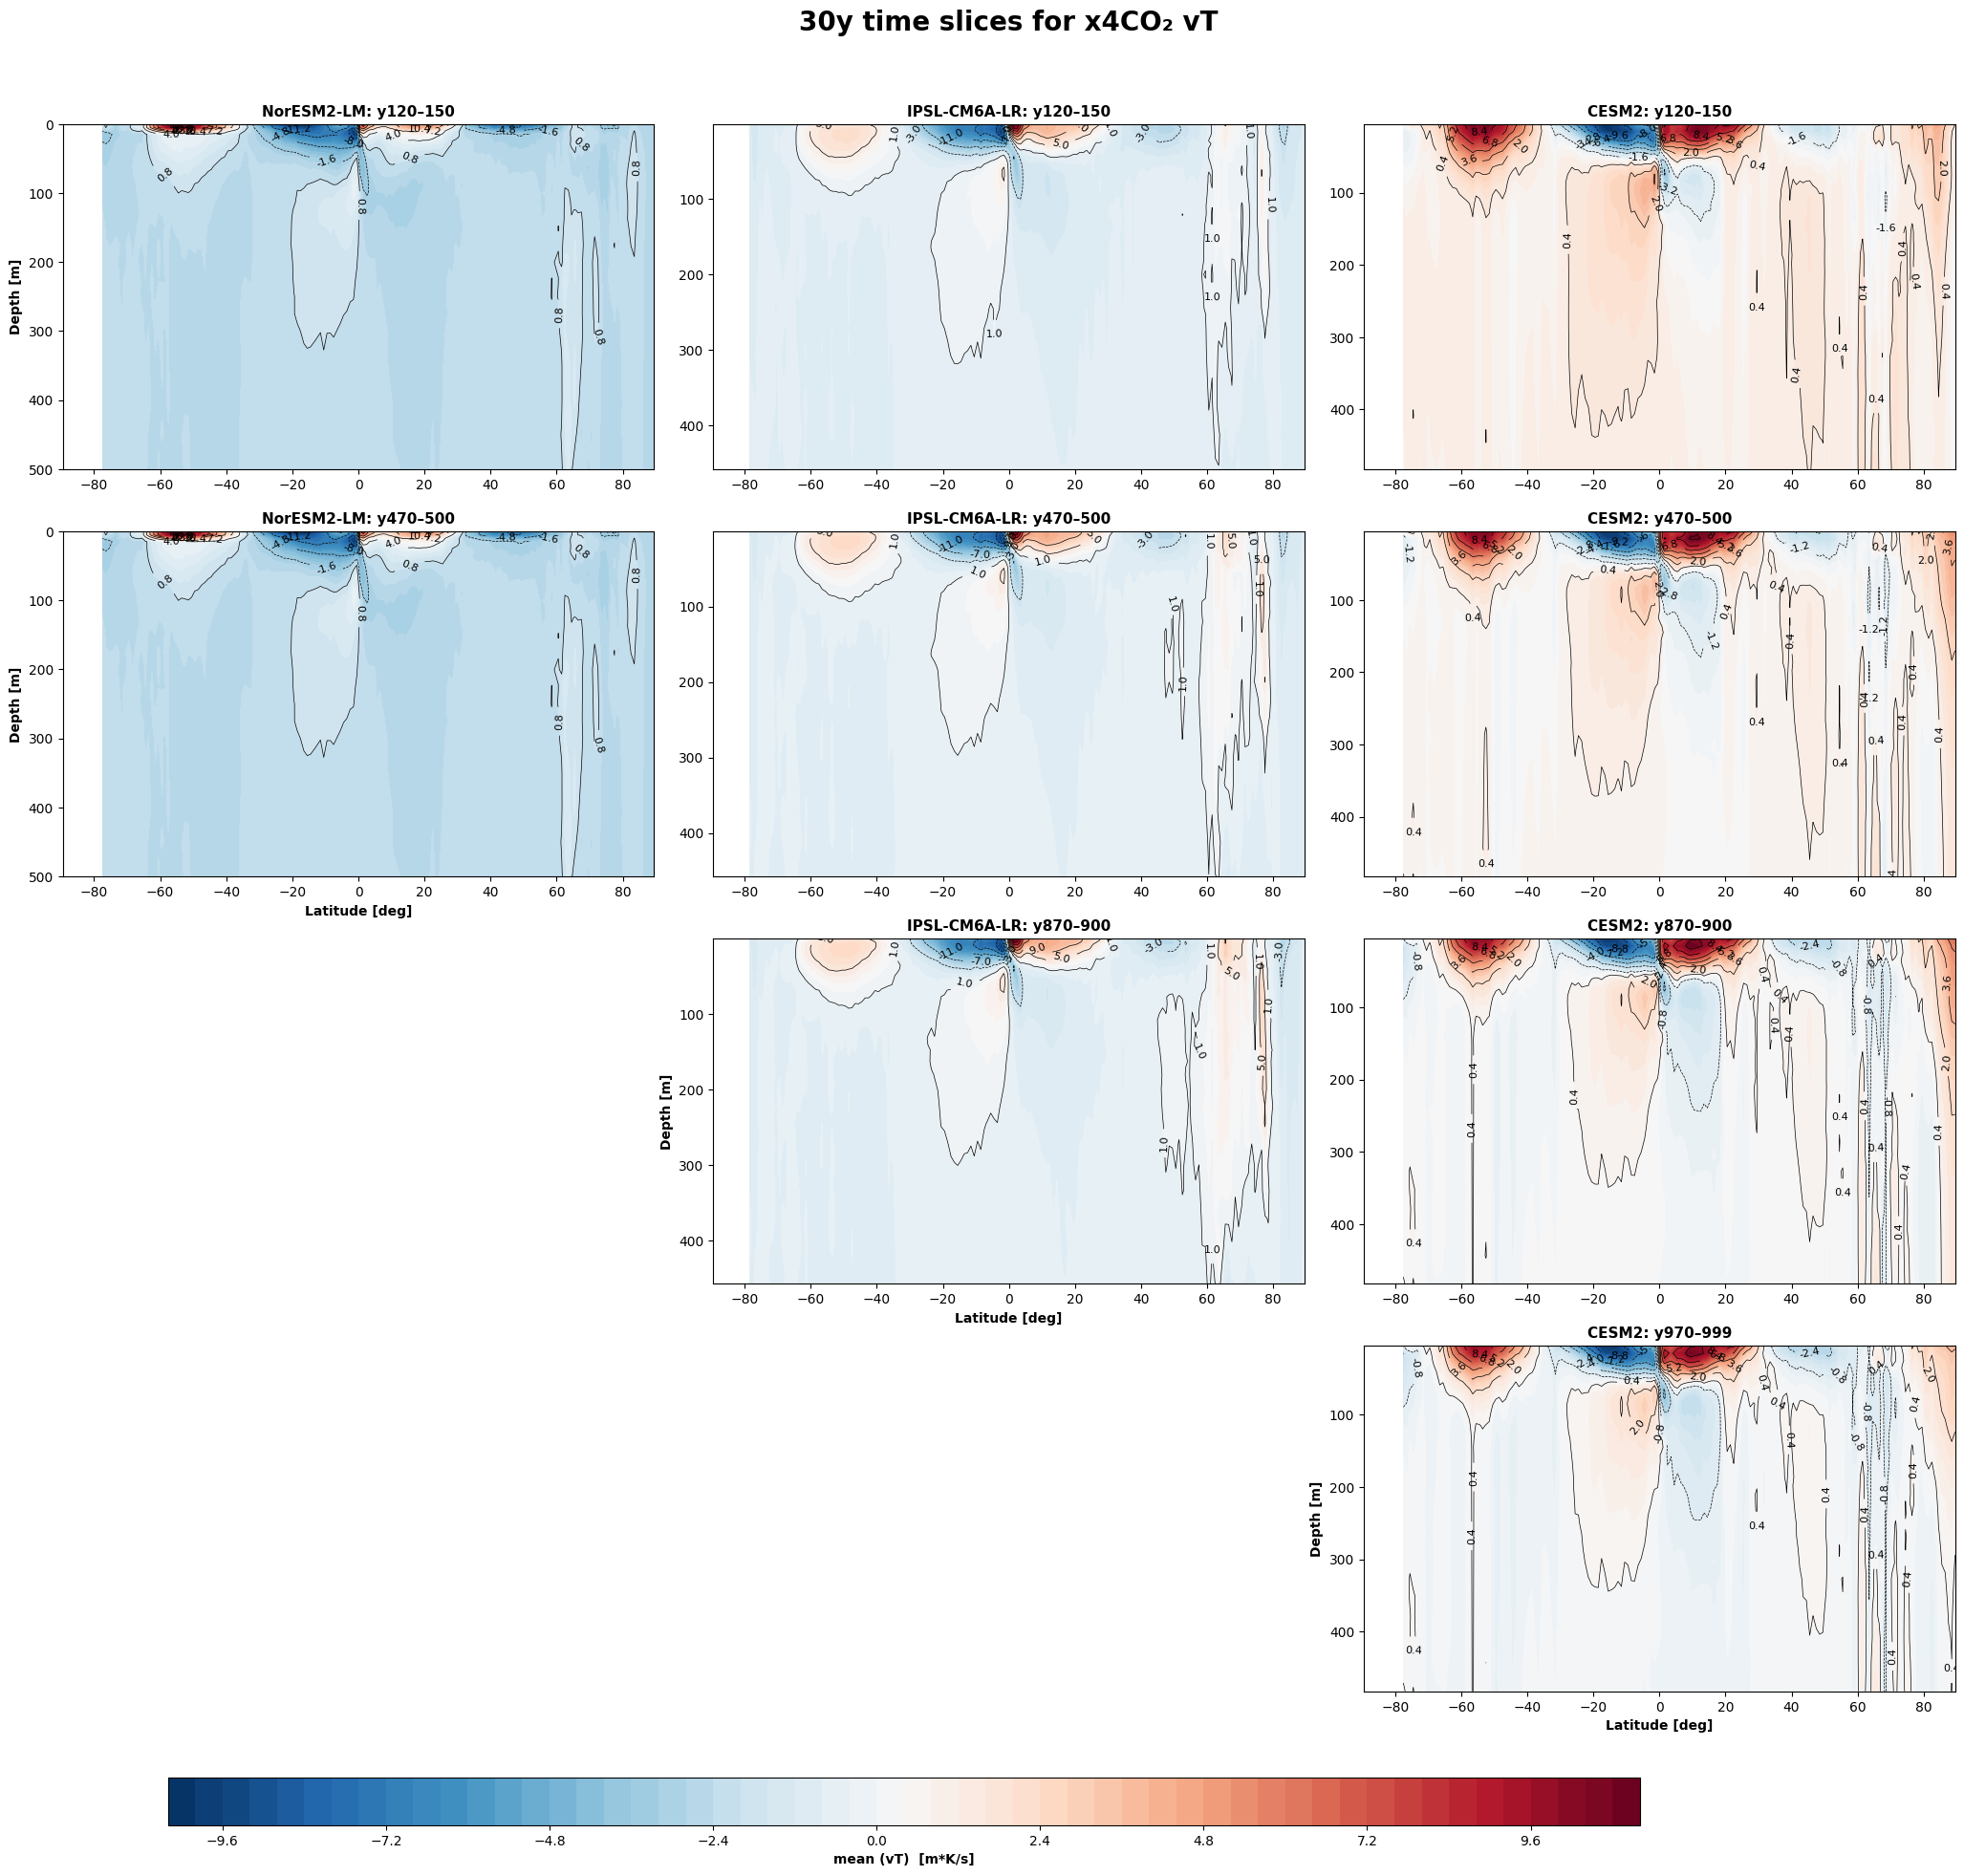

In [38]:
# ---- DATASETS ----
# Count rows for each column
col_rows = [len(g) for g in all_groups]
max_rows = max(col_rows)


# ---- FIGURE ----
fig = plt.figure(figsize=(22, 20))
gs = fig.add_gridspec(
    nrows=max_rows, ncols=3,
    height_ratios=[1]*max_rows,
    width_ratios=[1, 1, 1]
)

cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="white")


# =====================================================================
# PLOTTING LOOP
# =====================================================================

for col, group in enumerate(all_groups):      # loop over 3 columns
    n_panels = len(group)

    # Column 0 (NorESM2) starts at the top
    if col == 0:
        offset = 0
    else:
        offset = (max_rows - n_panels) // 2     # center columns 2 & 3

    for k, (data_anom, panel_title, model) in enumerate(group):

        # ------------------------ LAT & LEVELS ------------------------
        if model== "NorESM2-LM":        
    
            lat = total_pi_noresm2.lat
            lev = total_pi_noresm2.lev.sel(lev=slice(0, 500))
    
        elif model== "CESM2":        
    
            lat = total_pi_cesm2.lat
            lev = (total_pi_cesm2.lev/100).sel(lev=slice(0, 500*100))
    
        else:
            lat = total_pi_ipsl.lat
            lev = total_pi_ipsl.olevel.sel(olevel=slice(0, 500))
        
        # Position in grid (row, column)
        row = offset + k
        ax = fig.add_subplot(gs[row, col])

        # ------------------------ FILLED CONTOURS ------------------------
        im = ax.contourf(
            lat, lev, data_anom,
            levels=60, cmap="RdBu_r",
            
        )#vmin=-0.002, vmax=0.002
        

        # ------------------------ LINE CONTOURS ------------------------
        levels = im.levels
        neg_levels = levels[levels < 0]
        pos_levels = levels[levels > 0]

        anom_neg = ax.contour(lat, lev, data_anom,
                              levels=neg_levels[::4],
                              colors='k', linestyles='dashed', linewidths=0.5)
        anom_pos = ax.contour(lat, lev, data_anom,
                              levels=pos_levels[::4],
                              colors='k', linestyles='solid', linewidths=0.5)

        ax.clabel(anom_neg, inline=True, fmt="%1.1f", fontsize=8)
        ax.clabel(anom_pos, inline=True, fmt="%1.1f", fontsize=8)

        # ------------------------ AXES ------------------------
        ax.invert_yaxis()
        ax.set_title(panel_title, fontsize=11, fontweight='bold')

        # Left column gets y-label
        if col == 0 or (col == 1 and row == 2) or (col == 2 and row == 3):
            ax.set_ylabel("Depth [m]", fontweight="bold")
        
        # X-label only on the bottom panel of each column
        if (col == 0 and row == 1) or (col == 1 and row == 2) or (col == 2 and row == 3):
            ax.set_xlabel("Latitude [deg]", fontweight="bold")
        
# =====================================================================
# SHARED COLORBAR
# =====================================================================

cbar_ax = fig.add_axes([0.10, 0.03, 0.7, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label("mean (vT)  [m*K/s]", fontweight='bold')


# =====================================================================
# FINISH
# =====================================================================

fig.suptitle(
    "30y time slices for x4CO₂ vT",
    fontsize=20, weight='bold'
)

plt.subplots_adjust(
    left=0.05, right=0.95,
    top=0.92, bottom=0.10,
    wspace=0.10, hspace=0.18
)

plt.show()

In [39]:
# ---- DATASETS ----

noresm_datasets_anom = [
    (zonal_total_x4_120_150_noresm2 - zonal_total_pi_noresm2,  "NorESM2-LM: y120–150", "NorESM2-LM"),
    (zonal_total_x4_470_500_noresm2 - zonal_total_pi_noresm2,  "NorESM2-LM: y470–500", "NorESM2-LM"),
]

ipsl_datasets_anom = [
    (zonal_total_x4_120_150_ipsl - zonal_total_pi_ipsl, "IPSL-CM6A-LR: y120–150", "IPSL-CM6A-LR"),
    (zonal_total_x4_470_500_ipsl - zonal_total_pi_ipsl, "IPSL-CM6A-LR: y470–500", "IPSL-CM6A-LR"),
    (zonal_total_x4_870_900_ipsl - zonal_total_pi_ipsl, "IPSL-CM6A-LR: y870–900", "IPSL-CM6A-LR"),
]

cesm_datasets_anom = [
    (zonal_total_x4_120_150_cesm2 - zonal_total_pi_cesm2, "CESM2: y120–150", "CESM2"),
    (zonal_total_x4_470_500_cesm2 - zonal_total_pi_cesm2, "CESM2: y470–500", "CESM2"),
    (zonal_total_x4_870_900_cesm2 - zonal_total_pi_cesm2, "CESM2: y870–900", "CESM2"),
    (zonal_total_x4_970_999_cesm2 - zonal_total_pi_cesm2, "CESM2: y970–999", "CESM2"),
]

all_groups_anom = [noresm_datasets_anom, ipsl_datasets_anom, cesm_datasets_anom]

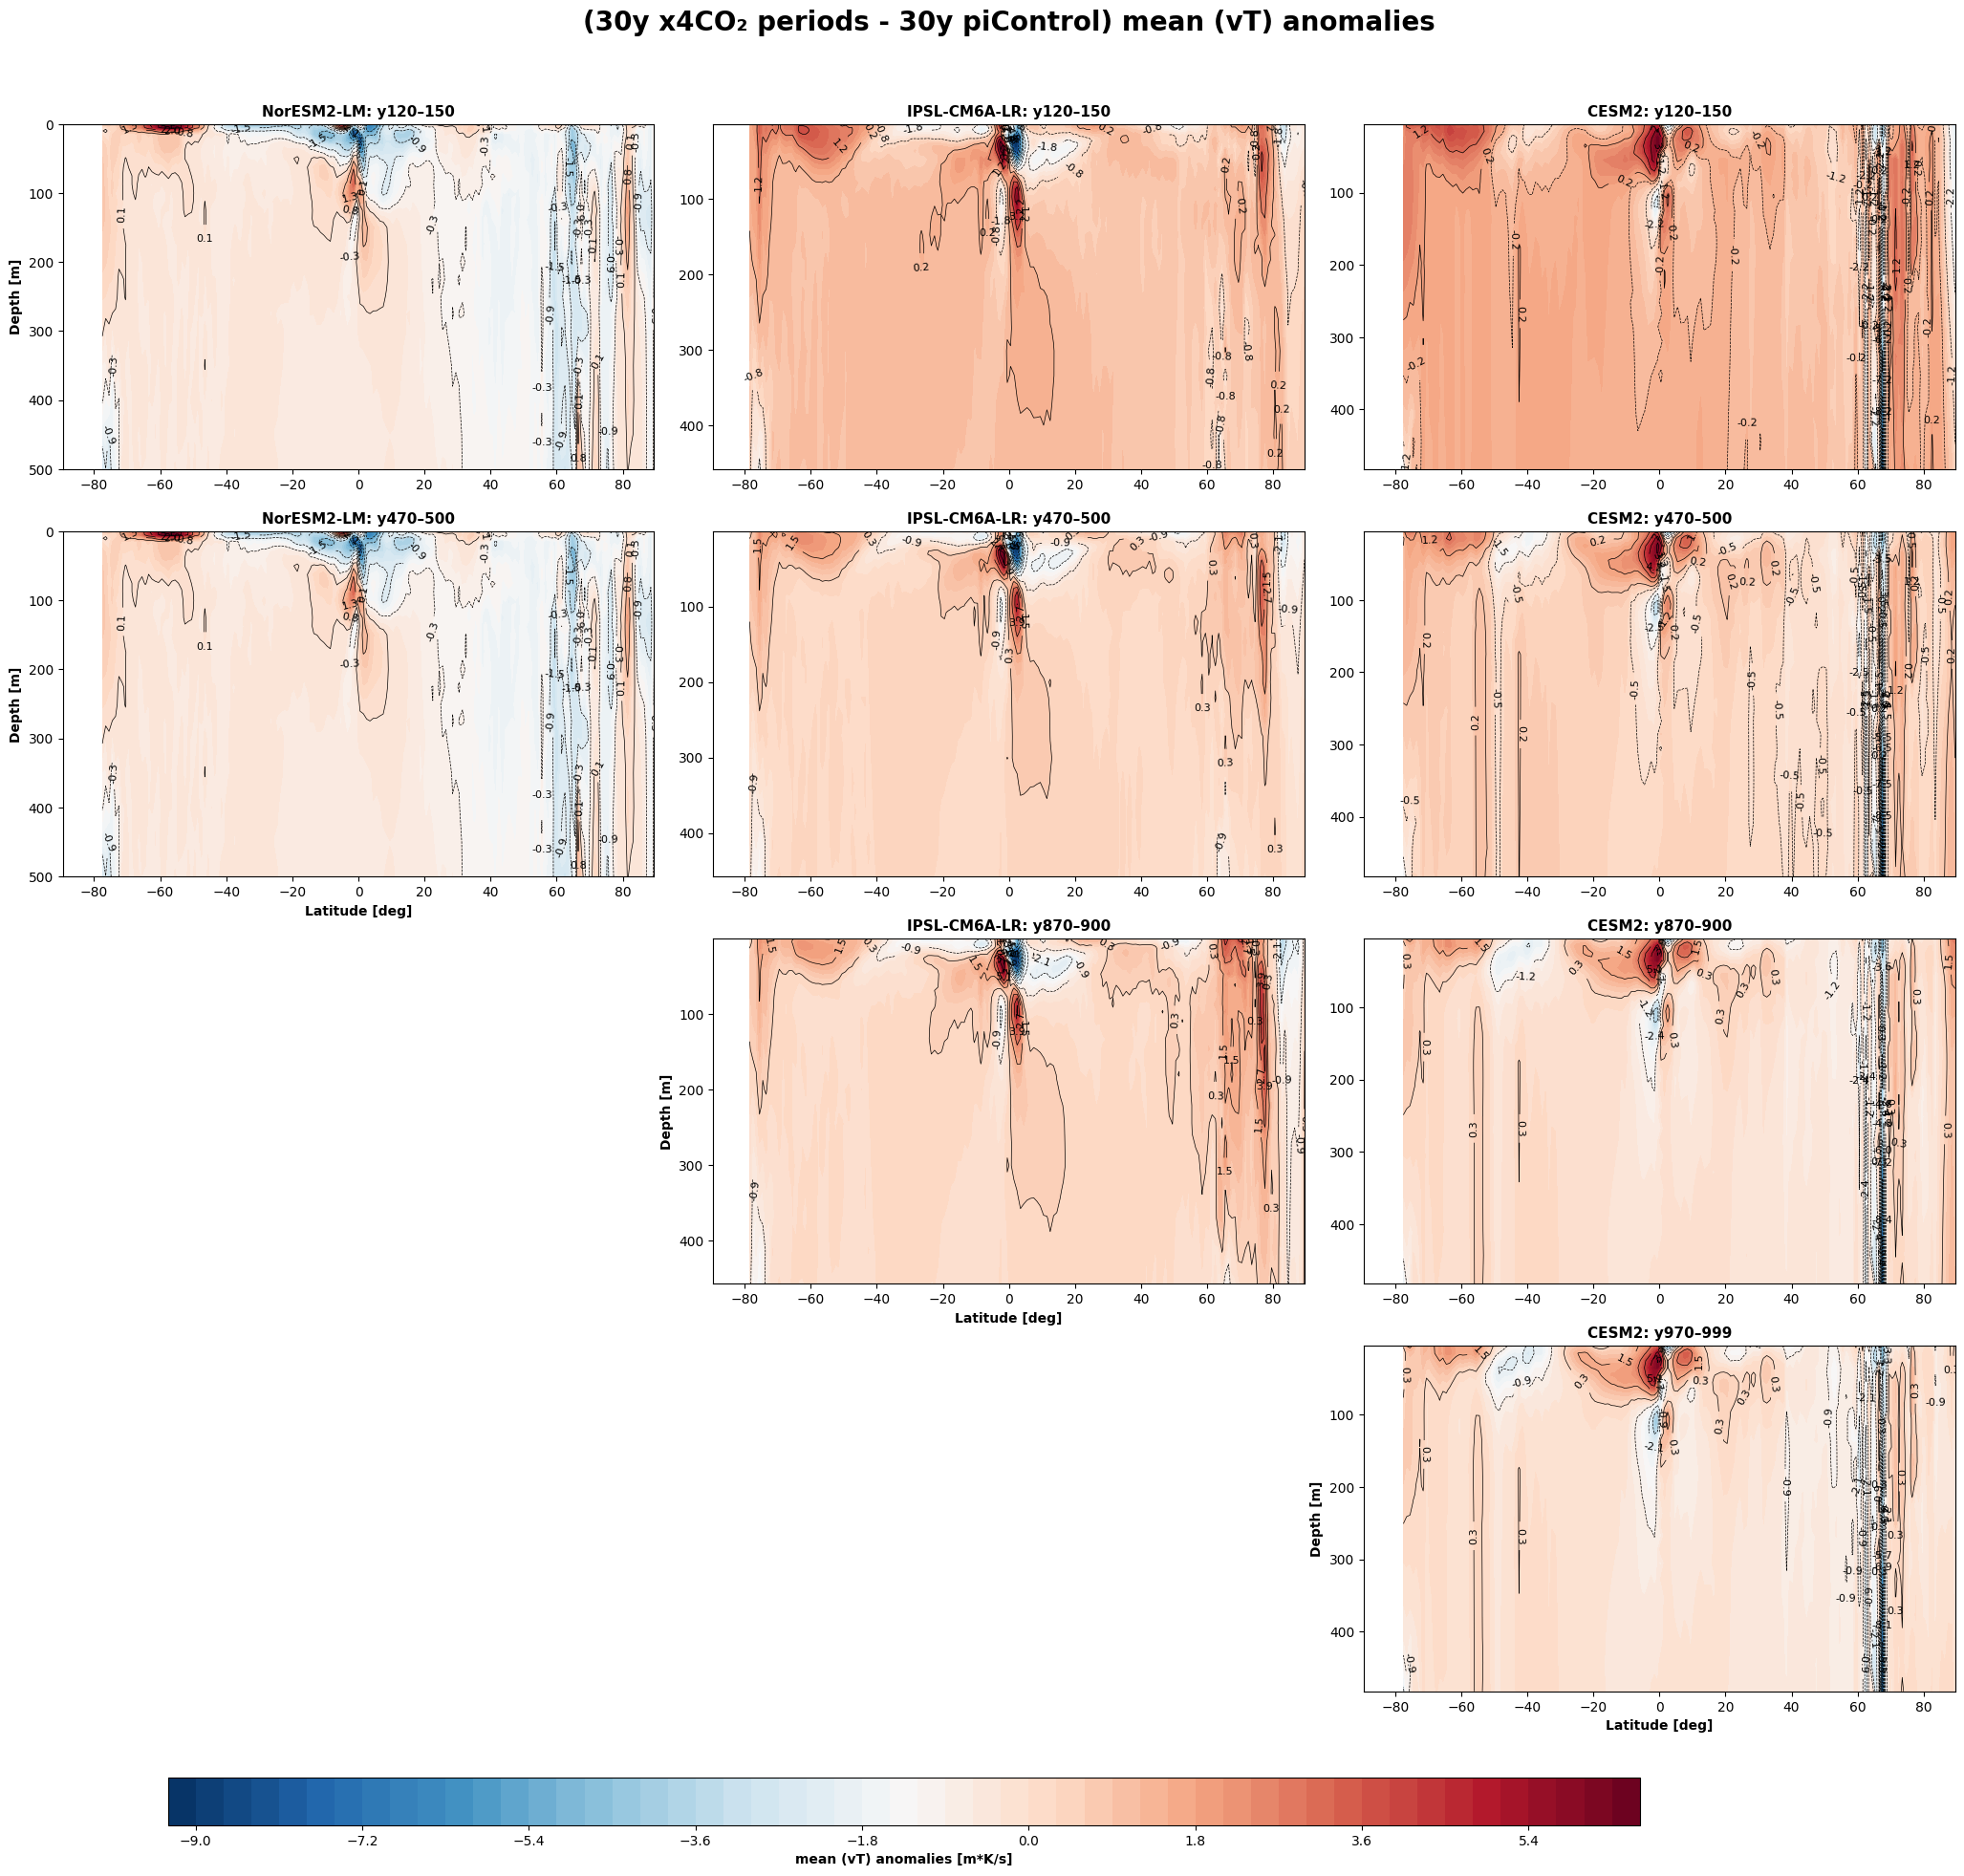

In [40]:
# ---- DATASETS ----
# Count rows for each column
col_rows = [len(g) for g in all_groups]
max_rows = max(col_rows)


# ---- FIGURE ----
fig = plt.figure(figsize=(22, 20))
gs = fig.add_gridspec(
    nrows=max_rows, ncols=3,
    height_ratios=[1]*max_rows,
    width_ratios=[1, 1, 1]
)

cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="white")


# =====================================================================
# PLOTTING LOOP
# =====================================================================

for col, group in enumerate(all_groups_anom):      # loop over 3 columns
    n_panels = len(group)

    # Column 0 (NorESM2) starts at the top
    if col == 0:
        offset = 0
    else:
        offset = (max_rows - n_panels) // 2     # center columns 2 & 3

    for k, (data_anom, panel_title, model) in enumerate(group):

        # ------------------------ LAT & LEVELS ------------------------
        if model== "NorESM2-LM":        
    
            lat = total_pi_noresm2.lat
            lev = total_pi_noresm2.lev.sel(lev=slice(0, 500))
    
        elif model== "CESM2":        
    
            lat = total_pi_cesm2.lat
            lev = (total_pi_cesm2.lev/100).sel(lev=slice(0, 500*100))
    
        else:
            lat = total_pi_ipsl.lat
            lev = total_pi_ipsl.olevel.sel(olevel=slice(0, 500))
        

        # Position in grid (row, column)
        row = offset + k
        ax = fig.add_subplot(gs[row, col])

        # ------------------------ FILLED CONTOURS ------------------------
        im = ax.contourf(
            lat, lev, data_anom,
            levels=60, cmap="RdBu_r",
            
        )# vmin=-0.002, vmax=0.002
        

        # ------------------------ LINE CONTOURS ------------------------
        levels = im.levels
        neg_levels = levels[levels < 0]
        pos_levels = levels[levels > 0]

        anom_neg = ax.contour(lat, lev, data_anom,
                              levels=neg_levels[::4],
                              colors='k', linestyles='dashed', linewidths=0.5)
        anom_pos = ax.contour(lat, lev, data_anom,
                              levels=pos_levels[::4],
                              colors='k', linestyles='solid', linewidths=0.5)

        ax.clabel(anom_neg, inline=True, fmt="%1.1f", fontsize=8)
        ax.clabel(anom_pos, inline=True, fmt="%1.1f", fontsize=8)

        # ------------------------ AXES ------------------------
        ax.invert_yaxis()
        ax.set_title(panel_title, fontsize=11, fontweight='bold')

        # Left column gets y-label
        if col == 0 or (col == 1 and row == 2) or (col == 2 and row == 3):
            ax.set_ylabel("Depth [m]", fontweight="bold")
        
        # X-label only on the bottom panel of each column
        if (col == 0 and row == 1) or (col == 1 and row == 2) or (col == 2 and row == 3):
            ax.set_xlabel("Latitude [deg]", fontweight="bold")
        
# =====================================================================
# SHARED COLORBAR
# =====================================================================

cbar_ax = fig.add_axes([0.10, 0.03, 0.7, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label("mean (vT) anomalies [m*K/s]", fontweight='bold')


# =====================================================================
# FINISH
# =====================================================================

fig.suptitle(
    "(30y x4CO₂ periods - 30y piControl) mean (vT) anomalies",
    fontsize=20, weight='bold'
)

plt.subplots_adjust(
    left=0.05, right=0.95,
    top=0.92, bottom=0.10,
    wspace=0.10, hspace=0.18
)

plt.show()